In [36]:
# DAY 5 - CONTEXTUAL FEATURE ANALYSIS
# Member 2 - Context Specialist Role


# =====================================================
# Import Libraries
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns





In [37]:
# Load Dataset (From Day 4 Output)


df = pd.read_csv("feature_engineered_ai4i.csv")

print("Dataset Loaded Successfully")
print("Shape:", df.shape)


Dataset Loaded Successfully
Shape: (10000, 18)


In [38]:
# SIMULATE CONTEXTUAL DATA (External Conditions)


np.random.seed(42)

df["ambient_temperature"] = np.random.normal(28, 5, len(df))
df["factory_load"] = np.random.randint(50, 101, len(df))
df["humidity"] = np.random.randint(30, 90, len(df))


In [39]:
# CONTEXTUAL FEATURE ENGINEERING


df["temp_gap"] = df["Process temperature [K]"] - df["ambient_temperature"]

df["load_torque_interaction"] = df["factory_load"] * df["Torque [Nm]"]

df["humidity_temp_interaction"] = df["humidity"] * df["Air temperature [K]"]



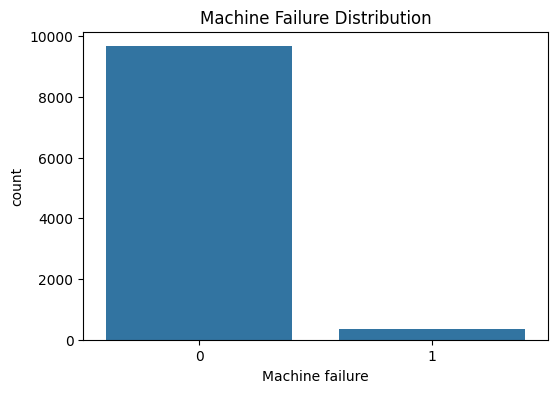

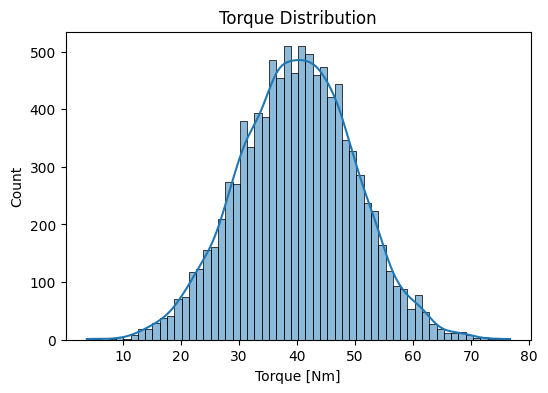

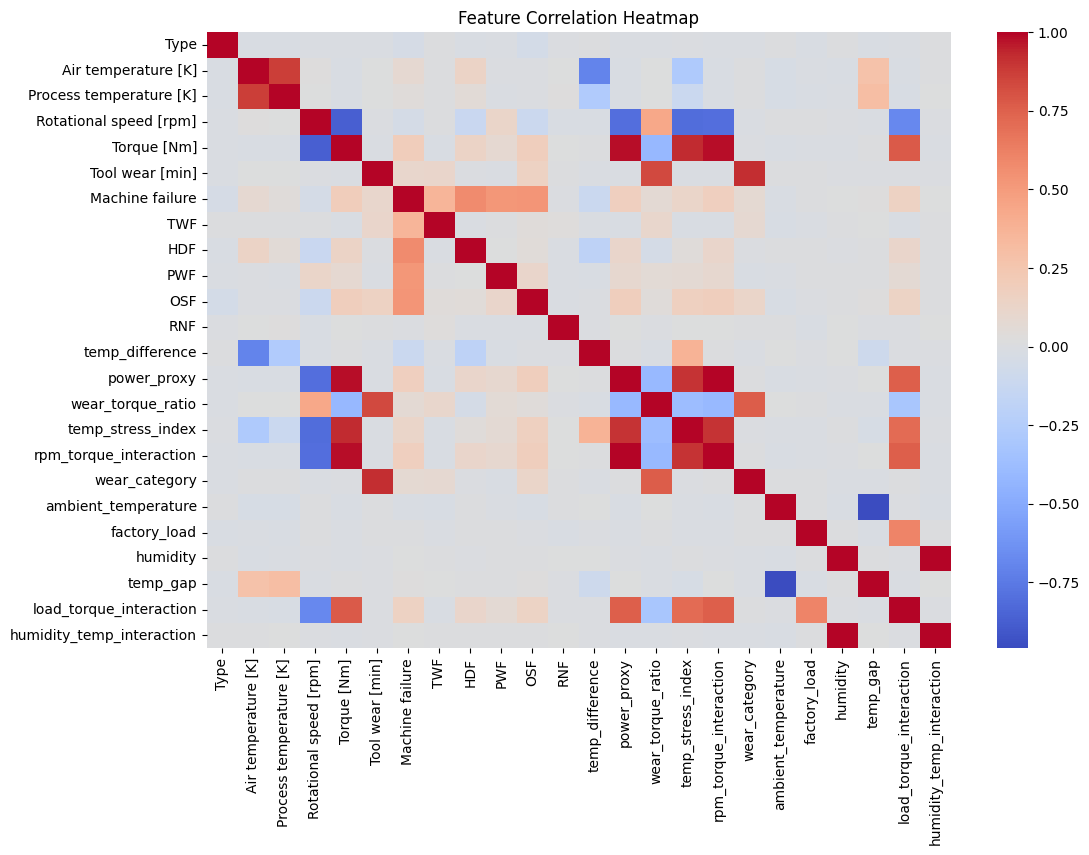

In [40]:
# VISUALIZATION - DATA UNDERSTANDING


# Machine Failure Distribution
plt.figure(figsize=(6,4))
sns.countplot(x=df["Machine failure"])
plt.title("Machine Failure Distribution")
plt.show()

# Torque Distribution
plt.figure(figsize=(6,4))
sns.histplot(df["Torque [Nm]"], kde=True)
plt.title("Torque Distribution")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()




In [41]:
# CONTEXT FEATURE SUMMARY


context_features = [
    "ambient_temperature",
    "factory_load",
    "humidity",
    "temp_gap",
    "load_torque_interaction",
    "humidity_temp_interaction"
]

print("\nContextual Feature Summary:")
print(df[context_features].describe())




Contextual Feature Summary:
       ambient_temperature  factory_load      humidity      temp_gap  \
count         10000.000000  10000.000000  10000.000000  10000.000000   
mean             27.989320     75.072800     59.485100    282.016240   
std               5.017312     14.804601     17.250088      5.270041   
min               8.387999     50.000000     30.000000    261.336343   
25%              24.637047     62.000000     44.000000    278.416649   
50%              27.987025     75.000000     60.000000    282.002857   
75%              31.355404     88.000000     74.000000    285.580420   
max              47.631189    100.000000     89.000000    301.983278   

       load_torque_interaction  humidity_temp_interaction  
count             10000.000000               10000.000000  
mean               3001.202810               17845.408270  
std                 963.568938                5174.704152  
min                 254.600000                8865.000000  
25%                229

In [42]:
# CORRELATION ANALYSIS WITH TARGET


print("\nCorrelation with Machine Failure:\n")

corr = df.corr(numeric_only=True)

print(
    corr["Machine failure"]
    .sort_values(ascending=False)
)





Correlation with Machine Failure:

Machine failure              1.000000
HDF                          0.575800
OSF                          0.531083
PWF                          0.522812
TWF                          0.362904
Torque [Nm]                  0.191321
power_proxy                  0.176039
rpm_torque_interaction       0.176039
load_torque_interaction      0.156620
temp_stress_index            0.123419
Tool wear [min]              0.105448
Air temperature [K]          0.082556
wear_category                0.080991
wear_torque_ratio            0.068416
Process temperature [K]      0.035946
temp_gap                     0.026463
humidity_temp_interaction    0.015318
humidity                     0.013440
factory_load                 0.008037
RNF                          0.004516
ambient_temperature         -0.017166
Type                        -0.036715
Rotational speed [rpm]      -0.044188
temp_difference             -0.111676
Name: Machine failure, dtype: float64


In [43]:
# SAVE FINAL DATASET FOR DAY 6

df.to_csv(
    "contextual_feature_engineered_ai4i.csv",
    index=False
)

print("\nSaved: contextual_feature_engineered_ai4i.csv")


Saved: contextual_feature_engineered_ai4i.csv
